# Simulation of trading strategy

### Trading Strategy Summary

Simulate a quarterly investment approach driven by Random Forest model predictions (pred_rf):

* Initial capital: $7,000
* Transaction fee: $5.00 per trade 
* Buy rule: At the start of a quarter, buy all stocks where pred_rf == True, splitting available capital equally.
* Hold rule: Hold each position until:
    * Stop loss: Price drops 20% from purchase price → sell immediately (at that quarter’s close in simulation).
    * Take profit: Price rises 30% from purchase price → sell immediately.
    * Otherwise, hold until the next quarter’s review.
* Reinvestment: Profits from sales are added to the cash pool and fully reinvested each quarter.
* Fractional shares: Allowed for simplicity.

### Performance Metrics

1. Total Return – final portfolio value vs. starting capital.
2. CAGR (Compound Annual Growth Rate): the annualized growth rate that would take you from your starting value to your ending value if you grew at a constant rate every year. It smooths out volatility to give a long-term growth measure.
3. Max Drawdown – worst peak-to-trough drop.
4. Sharpe Ratio – risk-adjusted return.
5. Win Rate – percentage of trades that made a profit.
6. Number of Trades – total trades executed.

In [4]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path

In [5]:
notebook_dir = Path().resolve()

# Data folder
data_folder = notebook_dir.parent / "Data"
data_folder.mkdir(exist_ok=True)  # ensures folder exists

In [6]:
rf_model_pred_path = data_folder / "rf_model_pred.csv"
df = pd.read_csv(rf_model_pred_path)

df.shape

(5078, 5)

In [7]:
df

,date,ticker,close,buy_signal,pred_rf
0,2001-12-31,6501.T,666.649902,False,False
1,2001-12-31,6758.T,1004.861816,False,False
2,2001-12-31,7203.T,383.685242,False,False
3,2001-12-31,7267.T,485.978973,False,False
4,2001-12-31,9432.T,22.953232,False,False
...,...,...,...,...,...
5073,2025-09-30,SIE.DE,230.250000,True,True
5074,2025-09-30,UBSG.SW,31.860001,True,True
5075,2025-09-30,ULVR.L,4569.608398,False,False
5076,2025-09-30,UNH,271.809998,False,False


In [ ]:
def backtest_fixed_capital(
    df,
    initial_capital=7000,
    transaction_fee=5.0,
    stop_loss_pct=-0.10,
    take_profit_pct=0.20
):
    """
    Backtest a trading strategy where cash is split equally among all predicted buy signals each quarter.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain columns: 'date', 'ticker', 'close', 'pred_rf'
        Sorted by date ascending.
    initial_capital : float
        Starting portfolio value.
    transaction_fee : float
        Fee per buy or sell transaction.
    stop_loss_pct : float
        Stop loss threshold (negative value, e.g., -0.10 = -10%).
    take_profit_pct : float
        Take profit threshold (positive value, e.g., 0.30 = +30%).
    
    Returns
    -------
    portfolio_history : pd.DataFrame
        Portfolio value and cash over time.
    trades : pd.DataFrame
        Record of all executed trades.
    metrics : dict
        Performance metrics of the strategy.
    """
    # Ensure sorting
    df = df.sort_values(['date', 'ticker']).reset_index(drop=True)

    # Track portfolio state
    cash = initial_capital
    positions = {}  # ticker -> { 'buy_price': float, 'shares': float, 'buy_date': date }
    portfolio_values = []
    trade_log = []

    for date, group in df.groupby('date'):
        # 1. Check existing positions for stop loss / take profit
        tickers_to_sell = []
        for ticker, pos in positions.items():
            current_price = group.loc[group['ticker'] == ticker, 'close'].values
            if len(current_price) == 0:
                continue
            current_price = current_price[0]
            change_pct = (current_price - pos['buy_price']) / pos['buy_price']

            if change_pct <= stop_loss_pct or change_pct >= take_profit_pct:
                # Sell
                sell_value = pos['shares'] * current_price
                cash += sell_value - transaction_fee
                trade_log.append({
                    'date': date,
                    'ticker': ticker,
                    'type': 'SELL',
                    'price': current_price,
                    'pnl': change_pct, # profit/loss from trade
                    'shares': pos['shares'],
                    'value': sell_value
                })
                tickers_to_sell.append(ticker)

        for ticker in tickers_to_sell:
            positions.pop(ticker)

        # 2. Get buy signals for this date
        buy_signals = group[group['pred_rf'] == True]['ticker'].tolist()

        # Exclude tickers that are already hold
        buy_signals = [t for t in buy_signals if t not in positions]

        if buy_signals and cash > 0:
            allocation_per_trade = cash / len(buy_signals)

            for ticker in buy_signals:
                price = group.loc[group['ticker'] == ticker, 'close'].values[0]
                shares = (allocation_per_trade - transaction_fee) / price
                if shares <= 0:
                    continue
                positions[ticker] = {
                    'buy_price': price,
                    'shares': shares,
                    'buy_date': date
                }
                trade_log.append({
                    'date': date,
                    'ticker': ticker,
                    'type': 'BUY',
                    'price': price,
                    'pnl': 0,
                    'shares': shares,
                    'value': shares * price
                })
                cash -= allocation_per_trade

        # 3. Calculate portfolio value
        value_positions = 0
        for ticker, pos in positions.items():
            current_price = group.loc[group['ticker'] == ticker, 'close'].values
            if len(current_price) == 0:
                continue
            value_positions += pos['shares'] * current_price[0]

        portfolio_value = cash + value_positions
        portfolio_values.append({'date': date, 'portfolio_value': portfolio_value, 'cash': cash})

    portfolio_history = pd.DataFrame(portfolio_values)
    trades = pd.DataFrame(trade_log)

    # change date datatype
    portfolio_history['date'] = pd.to_datetime(portfolio_history['date'])

    # Performance metrics
    final_value = portfolio_history['portfolio_value'].iloc[-1]
    years = (portfolio_history['date'].iloc[-1] - portfolio_history['date'].iloc[0]).days / 365.25
    cagr = (final_value / initial_capital) ** (1 / years) - 1
    rolling_max = portfolio_history['portfolio_value'].cummax()
    drawdowns = (portfolio_history['portfolio_value'] - rolling_max) / rolling_max
    max_drawdown = drawdowns.min()

    win_rate = np.mean([1 if pnl > 0 else 0 for pnl in trades['pnl']]) * 100 if not trades.empty else np.nan

    metrics = {
        'final_value': final_value,
        'total_return_pct': (final_value / initial_capital - 1) * 100,
        'cagr': cagr * 100,
        'max_drawdown_pct': max_drawdown * 100,
        'win_rate_pct': win_rate,
        'num_trades': len(trades)
    }

    return portfolio_history, trades, metrics


In [9]:
portfolio_history, trades, metrics = backtest_fixed_capital(df, initial_capital=7000)

In [10]:
# Performance results
print(f"Final Portfolio Value: ${metrics['final_value']:,.2f}")
print(f"Total Return: {metrics['total_return_pct']:.2f}%")
print(f"CAGR: {metrics['cagr']:.2f}%")
print(f"Max Drawdown: {metrics['max_drawdown_pct']:.2f}%")
print(f"Win Rate: {metrics['win_rate_pct']:.2f}%")
print(f"Number of Trades: {metrics['num_trades']}")

Final Portfolio Value: $42,759.69
Total Return: 510.85%
CAGR: 7.92%
Max Drawdown: -47.68%
Win Rate: 26.96%
Number of Trades: 1758


In [11]:
trades

,date,ticker,type,price,pnl,shares,value
0,2001-12-31,BAC,BUY,17.736494,0.0,43.569928,772.777778
1,2001-12-31,CAT,BUY,14.443380,0.0,53.503942,772.777778
2,2001-12-31,JNJ,BUY,31.259909,0.0,24.721050,772.777778
3,2001-12-31,KO,BUY,11.967840,0.0,64.571198,772.777778
4,2001-12-31,MMM,BUY,25.602137,0.0,30.184113,772.777778
...,...,...,...,...,...,...,...
1753,2025-09-30,BP.L,BUY,418.266785,0.0,1.400779,585.899474
1754,2025-09-30,DBK.DE,BUY,30.915001,0.0,18.951947,585.899474
1755,2025-09-30,OR.PA,BUY,388.149994,0.0,1.509467,585.899474
1756,2025-09-30,PEP,BUY,149.350006,0.0,3.922996,585.899474


In [12]:
portfolio_history

,date,portfolio_value,cash
0,2001-12-31,6955.000000,9.094947e-13
1,2002-03-31,7078.926077,-4.973799e-14
2,2002-06-30,6904.198893,8.526513e-14
3,2002-09-30,5920.177021,1.552005e+03
4,2002-12-31,5945.958861,0.000000e+00
...,...,...,...
91,2024-09-30,40323.636049,3.410605e-13
92,2024-12-31,39773.223890,3.410605e-13
93,2025-03-31,41379.783248,4.547474e-13
94,2025-06-30,40916.638948,1.591616e-12


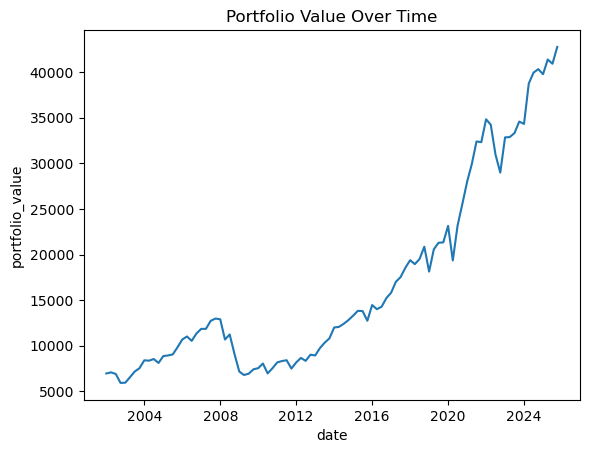

In [13]:
#plt.figure(figsize=(14, 7))
sns.lineplot(data=portfolio_history, x='date', y='portfolio_value')
plt.title('Portfolio Value Over Time')
plt.show()

# True strategy parameters

In [ ]:
def tune_params(df, 
                initial_capital=7000, 
                transaction_fee=5.0, 
                stop_losses=[-0.20, -0.10, -0.05], 
                take_profits=[0.10, 0.20, 0.30]):
    """
    Runs a grid search over stop loss and take profit values 
    to find the strategy with the highest CAGR.
    """
    results = []

    for sl in stop_losses:
        for tp in take_profits:
            _, _, metrics = backtest_fixed_capital(
                df,
                initial_capital=initial_capital,
                transaction_fee=transaction_fee,
                stop_loss_pct=sl,
                take_profit_pct=tp
            )
            results.append({
                'stop_loss': sl,
                'take_profit': tp,
                **metrics
            })

    results_df = pd.DataFrame(results)

    # Find best CAGR
    best_row = results_df.loc[results_df['cagr'].idxmax()]
    

    return results_df, best_row


In [ ]:
results_df, best_params = tune_params(df)

In [ ]:
print("Best Parameters:")
print(best_params)


Best Parameters:
stop_loss              -0.200000
take_profit             0.300000
final_value         56173.175393
total_return_pct      702.473934
cagr                    9.165227
max_drawdown_pct      -43.170435
win_rate_pct           33.616419
num_trades           1413.000000
Name: 2, dtype: float64
   stop_loss  take_profit   final_value  total_return_pct      cagr  \
2      -0.20          0.3  56173.175393        702.473934  9.165227   
1      -0.20          0.2  53361.148784        662.302125  8.929407   
0      -0.20          0.1  51782.060525        639.743722  8.791708   
3      -0.10          0.1  44672.625464        538.180364  8.117263   
5      -0.10          0.3  42759.691563        510.852737  7.918199   
8      -0.05          0.3  36076.877989        415.383971  7.148683   
4      -0.10          0.2  35646.987568        409.242680  7.094610   
7      -0.05          0.2  17810.706092        154.438658  4.010824   
6      -0.05          0.1   3798.726554        -45.73247

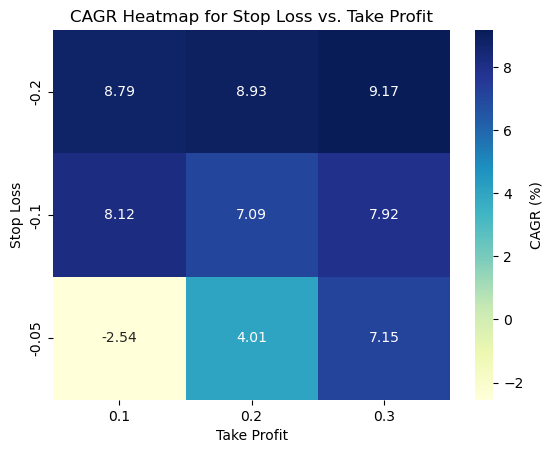

In [21]:
# Pivot for heatmap
pivot = results_df.pivot(index="stop_loss", columns="take_profit", values="cagr")

#plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'CAGR (%)'})
plt.title("CAGR Heatmap for Stop Loss vs. Take Profit")
plt.xlabel("Take Profit")
plt.ylabel("Stop Loss")
plt.show()


In [22]:
best_params

stop_loss              -0.200000
take_profit             0.300000
final_value         56173.175393
total_return_pct      702.473934
cagr                    9.165227
max_drawdown_pct      -43.170435
win_rate_pct           33.616419
num_trades           1413.000000
Name: 2, dtype: float64